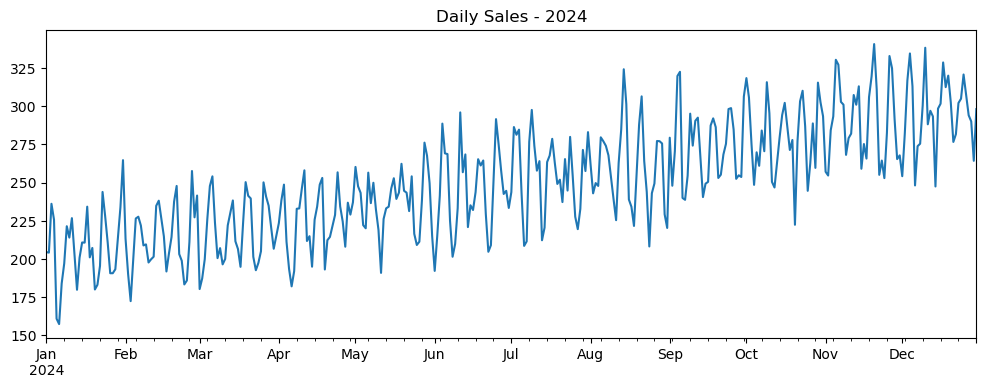

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

dates = pd.date_range("2024-01-01", periods=365, freq="D")

trend = np.linspace(200,300,365) #growth: 200 - 300 over the year
seasonality = 25 * np.sin(2 * np.pi * np.arange(365) / 7) # Weekly cycle, +-25
noise = rng.normal(0, 15, 365) # Honest randomness, σ=15

sales = trend + seasonality + noise

ts = pd.Series(sales, index=dates, name="daily_sales") # Index being dates unlocks resampling, rolling windows and calendar-aware slicing.
ts.plot(figsize=(12,4), title="Daily Sales - 2024")
plt.show()

In [2]:
train = ts[:"2024-10-31"] #Jan - Oct: 305 days
test = ts["2024-11-01":]
print(len(train), len(test))

305 60


In [12]:
# Plain Naive Forecast- forecast monday based on sunday alone.

naive_forecast = pd.Series(train.iloc[-1], index=test.index)

from sklearn.metrics import mean_absolute_error
mae_naive = mean_absolute_error(test, naive_forecast)
print(f"Naive MAE: {mae_naive:.2f}")

naive_test_df = pd.DataFrame({
    "NAIVE" : mae_naive,
    "TEST" : test
})

print(naive_test_df.head(10))


Naive MAE: 20.80
                NAIVE        TEST
2024-11-01  20.795005  257.150638
2024-11-02  20.795005  254.675894
2024-11-03  20.795005  284.295541
2024-11-04  20.795005  293.355213
2024-11-05  20.795005  330.420571
2024-11-06  20.795005  327.199211
2024-11-07  20.795005  302.872954
2024-11-08  20.795005  301.026210
2024-11-09  20.795005  268.200711
2024-11-10  20.795005  279.137772


In [26]:
# Seasonal Naive - tracks what it was like monday last week

seasonal_naive = pd.Series(np.tile(train.iloc[-7:].values, 9)[:len(test)], index=test.index)

mae_seasonal = mean_absolute_error(test, seasonal_naive)
print(f"Seasonal Naive MAE: {mae_seasonal:.2f}")
print()

comparison_df = pd.DataFrame({
    "Actual" : test,
    "Seasonal_naive": seasonal_naive
})

print(comparison_df.head(10))
print()
print(f"Oct-25:, {train["2024-10-25"]:.2f}")

Seasonal Naive MAE: 20.23

                Actual  Seasonal_naive
2024-11-01  257.150638      244.670212
2024-11-02  254.675894      262.689592
2024-11-03  284.295541      288.782049
2024-11-04  293.355213      259.684387
2024-11-05  330.420571      315.470240
2024-11-06  327.199211      302.687078
2024-11-07  302.872954      293.443712
2024-11-08  301.026210      244.670212
2024-11-09  268.200711      262.689592
2024-11-10  279.137772      288.782049

Oct-25:, 244.67
